# Лабораторная работа 1. Описательные статистики

Загрузите датасет players.csv из папки datasets

# Задание 1
Для каждого признака посчитайте следующие описательные статистики:

1. Среднее

2. Медиана

3. Стандартное отклонение

4. Коэффициента ассиметрии и эксцесса

5. Межквартильный размах

6. Процентили 5% и 95%

Произведите анализ полученных статистик

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [33]:
df = pd.read_csv("players.csv")
df.head()

,sofifa_id,overall,value_eur,wage_eur,age,height_cm,weight_kg
0,158023,93,78000000.0,320000.0,34,170,72
1,188545,92,119500000.0,270000.0,32,185,81
2,20801,91,45000000.0,270000.0,36,187,83
3,190871,91,129000000.0,270000.0,29,175,68
4,192985,91,125500000.0,350000.0,30,181,70


In [34]:
df_statistics = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "std": df.std(),
    "skew": df.skew(),
    "kurtosis": df.kurt(),
    "IQR": df.quantile(0.72) - df.quantile(0.25),
    "perc-5": df.quantile(0.05),
    "perc-95": df.quantile(0.95)
})

df_statistics

,mean,median,std,skew,kurtosis,IQR,perc-5,perc-95
sofifa_id,2.314681e+05,236543.0,2.703972e+04,-1.460740,5.385233,37431.86,184133.9,263046.1
overall,6.577218e+01,66.0,6.880232e+00,0.081602,0.091004,9.00,54.0,77.0
value_eur,2.850452e+06,975000.0,7.613700e+06,8.186343,97.897519,1325000.00,180000.0,11500000.0
wage_eur,9.017989e+03,3000.0,1.947018e+04,6.472150,63.067340,6000.00,500.0,37150.0
age,2.521082e+01,25.0,4.748235e+00,0.431183,-0.413828,7.00,18.0,34.0
height_cm,1.812997e+02,181.0,6.863179e+00,-0.039905,-0.325940,9.00,170.0,193.0
weight_kg,7.494303e+01,75.0,7.069434e+00,0.242040,0.056305,9.00,64.0,87.0


# Задание 2
Для каждого признака нарисуйте следующие графики:

1. Гистограмма с плотностью распределения

2. Ящик с усами

Что можно сказать глядя на эти графики?

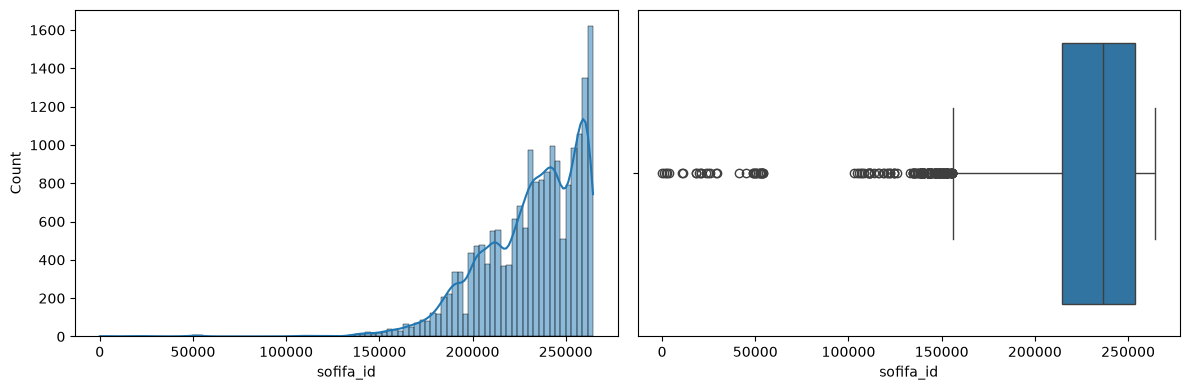

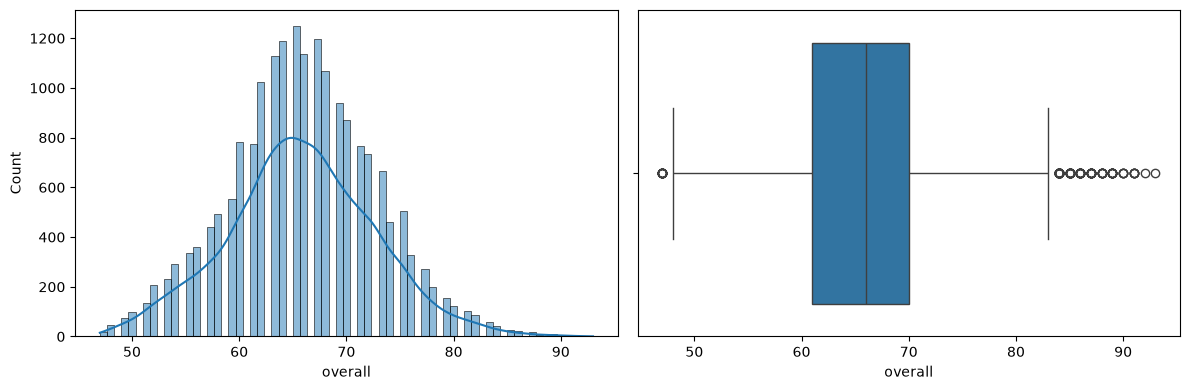

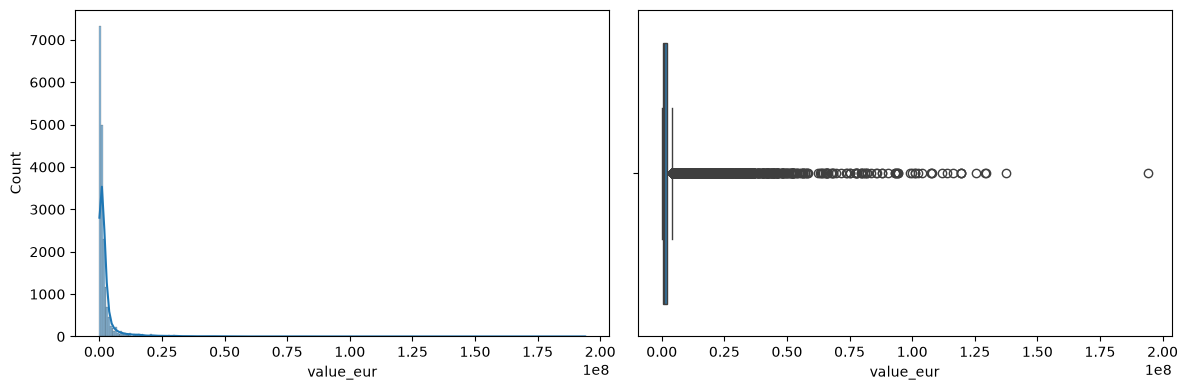

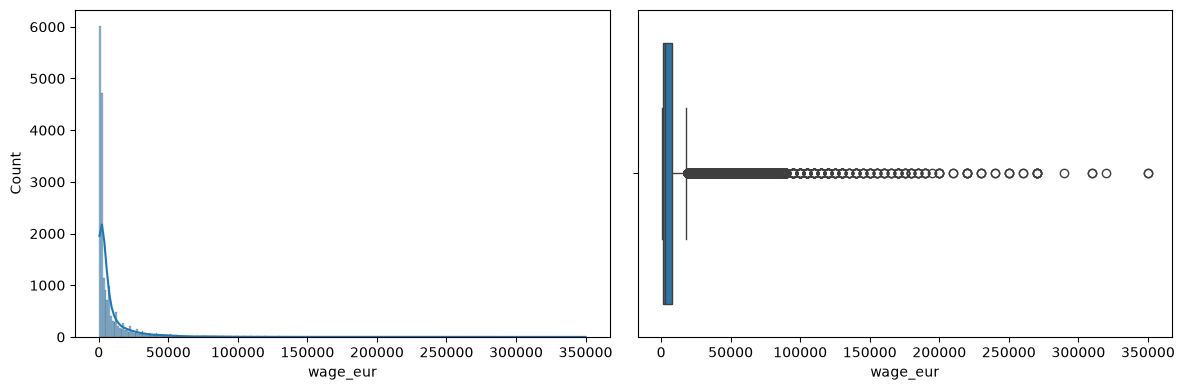

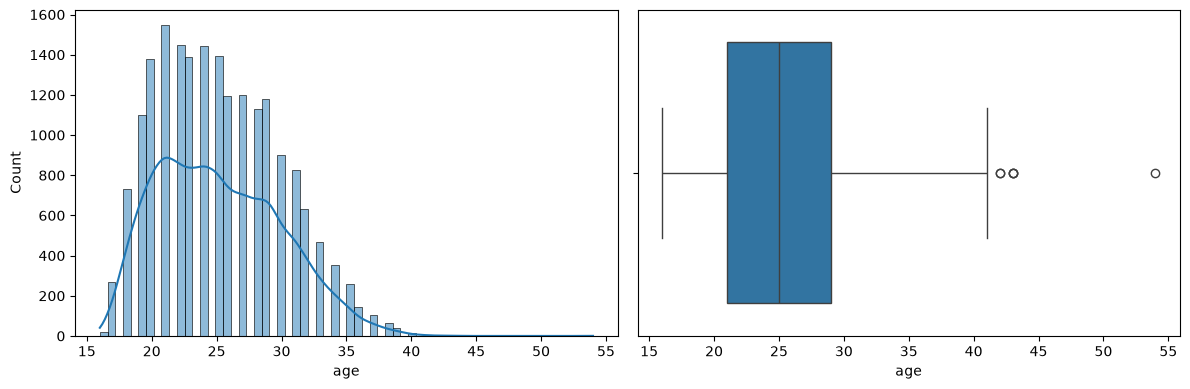

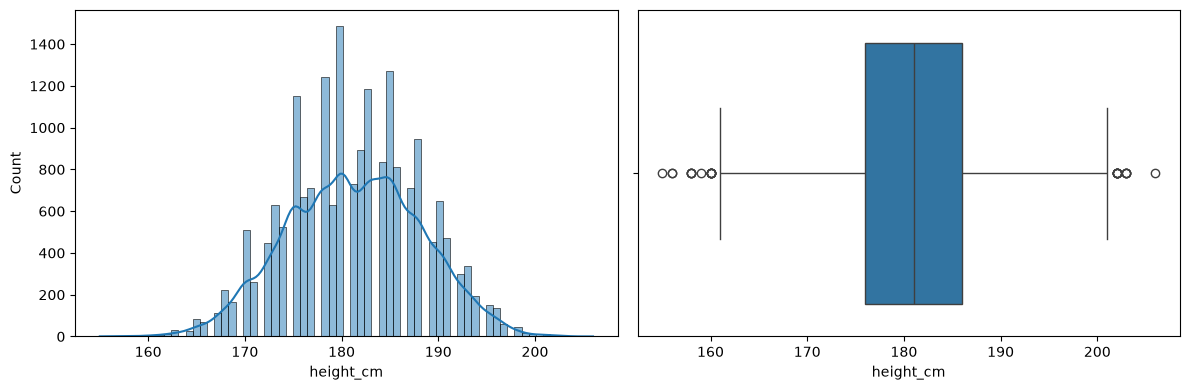

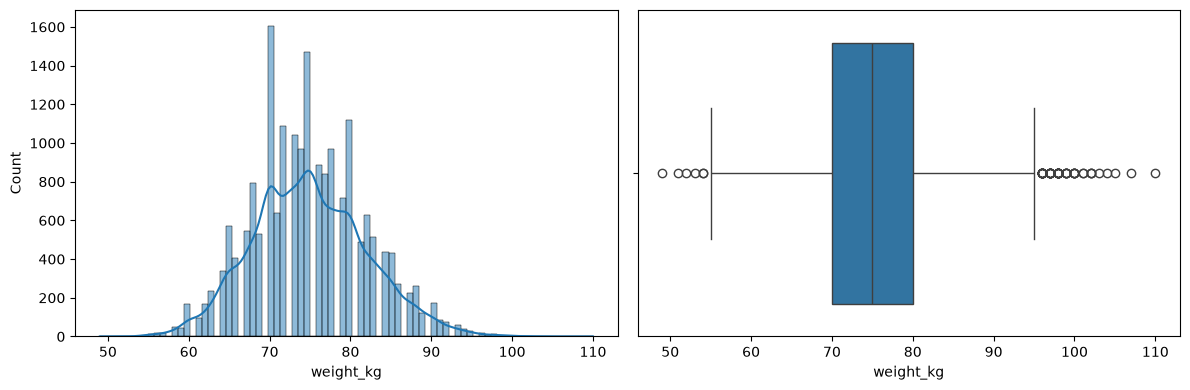

In [35]:


for col in df.columns:
    figs, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(
        df[col],
        kde=True,
        bins='auto',
        ax=axes[0]
    )

    sns.boxplot(x = df[col], ax=axes[1])

    plt.tight_layout()
    plt.show()

# Задание 3
Выберете признак, подозрительный на нормальное распределение. Для этого признака проверьте гитотезу об нормальном распределении на уровне значимости 0.05 используя как минимум 2 статистических теста. Нарисуйте график Q/Q плот.

In [39]:
x = df['overall']

shapiro_stat, shapiro_p = stats.normaltest(x)
print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

jb_stat, jb_p = stats.jarque_bera(x)
print(f"Jarque-Bera: stat = {jb_stat:.4f}, p = {jb_p:.4f}")

Shapiro-Wilk: W = 27.4669, p-value = 0.0000
Jarque-Bera: stat = 27.9382, p = 0.0000


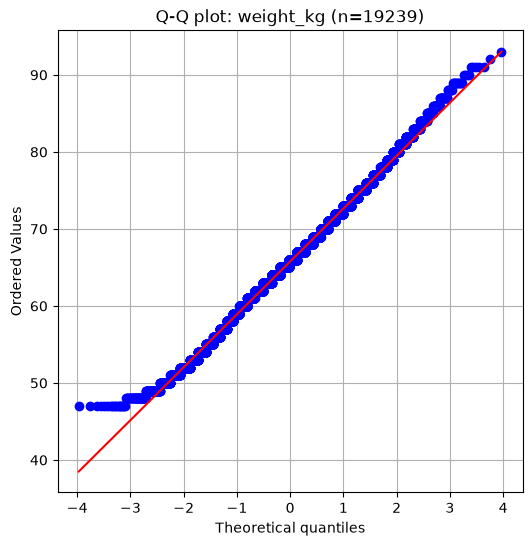

In [38]:
plt.figure(figsize=(6, 6))
stats.probplot(x, dist="norm", plot=plt)
plt.title(f"Q-Q plot: {col} (n={len(x)})")
plt.grid(True)
plt.show()

Распределение статистически отличается от нормального.